# **SQL IN R**

## Loading the Files

In [ ]:
raw_data_url <- "https://raw.githubusercontent.com/dheerium/northstar-analytics/main/data/"

orders     <- read.csv(paste0(raw_data_url, "orders.csv"))
deliveries <- read.csv(paste0(raw_data_url, "deliveries.csv"))
drivers    <- read.csv(paste0(raw_data_url, "drivers.csv"))
customers  <- read.csv(paste0(raw_data_url, "customers.csv"))
complaints <- read.csv(paste0(raw_data_url, "complaints.csv"))
incidents  <- read.csv(paste0(raw_data_url, "incidents.csv"))
app_events <- read.csv(paste0(raw_data_url, "app_events.csv"))
vehicles   <- read.csv(paste0(raw_data_url, "vehicles.csv"))
hubs       <- read.csv(paste0(raw_data_url, "hubs.csv"))

cat("### Loaded Successfully ###\n")
cat("\norders         - ", nrow(orders), "rows\n")
cat("deliveries     - ", nrow(deliveries), "rows\n")
cat("customers      - ", nrow(customers), "rows\n")
cat("drivers        - ", nrow(drivers), "rows\n")
cat("vehicles       - ", nrow(vehicles), "rows\n")
cat("incidents      - ", nrow(incidents), "rows\n")
cat("complaints     - ", nrow(complaints), "rows\n")
cat("app_events     - ", nrow(app_events), "rows\n")
cat("hubs           - ", nrow(hubs), "rows\n")

### Loaded Successfully ###

orders         -  1250 rows
deliveries     -  950 rows
customers      -  650 rows
drivers        -  170 rows
vehicles       -  120 rows
incidents      -  280 rows
complaints     -  320 rows
app_events     -  640 rows
hubs           -  8 rows


## Installing Packages

In [ ]:
install.packages(c('sqldf', 'ggplot2', 'dplyr', 'lubridate', 'scales', 'DBI', 'RSQLite'))

library(sqldf)
library(ggplot2)
library(dplyr)
library(lubridate)
library(scales)
library(DBI)
library(RSQLite)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




## Data Cleaning

In [ ]:
# Standardise zone names by fixing the capitalization
orders$pickup_zone  <- tools::toTitleCase(tolower(trimws(orders$pickup_zone)))
orders$dropoff_zone <- tools::toTitleCase(tolower(trimws(orders$dropoff_zone)))

# Check the cleaned zones
cat("Normalised categorical zone data\n\n")

cat("Count of Pickup Zones:\n")
print(table(orders$pickup_zone))

cat("\n\nCount of Priority Levels:\n")
print(table(orders$priority_level))

cat("\n\nCount of Service Types:\n")
print(table(orders$service_type))

cat("\n\nCount of Delivery Statuses:\n")
print(table(deliveries$delivery_status))

Normalised categorical zone data

Count of Pickup Zones:

  Airport   Central       Ctr      East     North Riverside     South      West 
      144       158        80       207       174       151       181       155 


Count of Priority Levels:

Critical     High      Low   Medium 
      91      308      348      503 


Count of Service Types:

 Business   Medical    Parcel Passenger    Retail 
      165       139       308       341       297 


Count of Delivery Statuses:

Delayed  Failed  OnTime 
    202     132     616 


## Data Quality Assessment
A preliminary check reveals missing values in several datasets.
Zone name inconsistencies in orders have been standardised for SQL querying.
Full missing value treatment is performed in Notebook 2 (Python) where we will use Pandas to provide more powerful data cleaning tools.

Checking for missing values in all the dateset

In [ ]:

cat("       /// MISSING VALUES CHECK ///\n\n")
cat("orders          :    ", sum(is.na(orders)), "   missing values\n")
cat("deliveries      :    ", sum(is.na(deliveries)), "  missing values\n")
cat("customers       :    ", sum(is.na(customers)), "  missing values\n")
cat("drivers         :    ", sum(is.na(drivers)), "   missing values\n")
cat("vehicles        :    ", sum(is.na(vehicles)), "   missing values\n")
cat("incidents       :    ", sum(is.na(incidents)), "  missing values\n")
cat("complaints      :    ", sum(is.na(complaints)), "  missing values\n")
cat("app_events      :    ", sum(is.na(app_events)), "   missing values\n\n\n")

# Checking column names
cat("           /// COLUMN NAMES ///\n\n")
cat("orders columns:-\n")
print(names(orders))
cat("\n\n\n")
cat("deliveries columns:-\n")
print(names(deliveries))

       /// MISSING VALUES CHECK ///

orders          :     0    missing values
deliveries      :     14   missing values
customers       :     20   missing values
drivers         :     7    missing values
vehicles        :     4    missing values
incidents       :     17   missing values
complaints      :     16   missing values
app_events      :     0    missing values


           /// COLUMN NAMES ///

orders columns:-
 [1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"



deliveries columns:-
 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"      

## **SQL Queries**

### SQL Query 1 - Delivery Failure Rate by Service Type

In [ ]:

query1 <- sqldf("
  SELECT
    o.service_type,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) AS ontime,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS failure_rate_pct
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY failure_rate_pct DESC
")

print(query1)

  service_type total_orders failed delayed ontime failure_rate_pct
1     Business          126     25      28     73            19.84
2      Medical          108     16      22     70            14.81
3    Passenger          262     38      53    171            14.50
4       Retail          224     28      50    146            12.50
5       Parcel          230     25      49    156            10.87


**Interpretation**: Business services have the highest failure rate (19.84%), nearly double that of Parcel services (10.87%). Premium and time-critical services are disproportionately affected, suggesting NorthStar's operational issues impact its most valuable contracts most severely.

### SQL Query 2

In [ ]:
query2 <- sqldf("
  SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS failure_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone, h.hub_type
  ORDER BY failure_rate_pct DESC
")

print(query2)

        hub_name      zone  hub_type total_deliveries failed delayed
1  Midtown Relay   Central  Charging              128     26      22
2   Central Core   Central   Control              115     23      25
3    Airport Hub   Airport  Dispatch              104     15      27
4      West Gate      West  Dispatch              127     16      28
5 North Exchange     North  Dispatch              136     17      26
6  Riverside Hub Riverside Warehouse              115     14      25
7     South Link     South  Dispatch              106     10      26
8      East Dock      East Warehouse              119     11      23
  failure_rate_pct avg_customer_rating
1            20.31                3.88
2            20.00                3.67
3            14.42                3.88
4            12.60                3.92
5            12.50                3.84
6            12.17                3.88
7             9.43                3.95
8             9.24                3.90


**Interpretation**: Midtown Relay (20.31%) and Central Core (20.00%) are the worst performing hubs, both of are located in the Central zone. Central Core also has the lowest customer rating (3.67). East Dock and South Link perform best at under 10%, indicating clear geographic performance disparities across NorthStar's network.

### SQL Query 3

In [ ]:
query3 <- sqldf("
  SELECT
    manual_route_override_count,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS failure_rate_pct
  FROM deliveries
  WHERE manual_route_override_count IS NOT NULL
  GROUP BY manual_route_override_count
  ORDER BY manual_route_override_count
")

print(query3)

  manual_route_override_count total_deliveries failed delayed failure_rate_pct
1                           0              399     46      78            11.53
2                           1              310     51      67            16.45
3                           2              153     22      34            14.38
4                           3               57     10      14            17.54
5                           4               23      3       5            13.04
6                           5                7      0       4             0.00
7                           7                1      0       0             0.00


**Interpretation**: Deliveries with 1 override (16.45%) and 3 overrides (17.54%) show higher failure rates than zero overrides (11.53%). Even a single manual route change significantly increases failure risk, supporting concerns that override behaviour reflects poor route planning rather than genuine
road condition responses.

### SQL Query 4

In [ ]:
query4 <- sqldf("
  SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    dr.years_experience,
    dr.training_score,
    dr.driver_rating,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS failure_rate_pct,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  HAVING total_deliveries >= 5
  ORDER BY failure_rate_pct DESC
  LIMIT 10
")

print(query4)

   driver_id base_zone employment_type years_experience training_score
1       D092      East        FullTime               15           88.2
2       D104      WEST        FullTime               15           87.7
3       D024 RiverSide        PartTime                8           71.4
4       D010      West        FullTime                8           70.0
5       D144      West        FullTime                6           85.0
6       D143   CENTRAL        FullTime                6           68.5
7       D095      WEST        FullTime               12           99.0
8       D005     north        FullTime                3           69.7
9       D165     North        PartTime               10           82.2
10      D133     South        Contract               12           88.2
   driver_rating total_deliveries failed failure_rate_pct avg_overrides
1           4.24                5      3            60.00          0.40
2           3.45                7      4            57.14          1.71
3  

**Interpretation**: Driver D092 fails 60% of deliveries despite 15 years experience and an 88.2 training score which suggest that experience alone does not guarantee performance. The West zone appears repeatedly among high-failure drivers, reinforcing hub-level issues. Part-time driver D024 has the lowest rating (3.35) among top failures, flagging employment type as a potential risk factor.

### SQL Query 5

In [ ]:
query5 <- sqldf("
  SELECT
    o.service_type,
    o.pickup_zone,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT c.complaint_id) AS total_complaints,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(100.0 * COUNT(DISTINCT c.complaint_id) / COUNT(DISTINCT o.order_id), 2) AS complaint_rate_pct
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  LEFT JOIN complaints c ON o.order_id = c.order_id
  GROUP BY o.service_type, o.pickup_zone
  ORDER BY complaint_rate_pct DESC
  LIMIT 10
")

print(query5)

   service_type pickup_zone total_orders total_complaints failed_deliveries
1       Medical         Ctr            3                3                 1
2        Retail   Riverside           36               15                 3
3      Business       North           25               10                 5
4       Medical       North           19                7                 6
5       Medical     Central           18                6                 2
6     Passenger   Riverside           39               13                 4
7        Retail     Central           39               13                 7
8        Retail       South           42               14                 0
9      Business   Riverside           22                7                 5
10      Medical        East           22                7                 1
   complaint_rate_pct
1              100.00
2               41.67
3               40.00
4               36.84
5               33.33
6               33.33
7         

**Interpretation**: Medical-Central shows a 100% complaint rate (3/3 orders). Retail-South has 14 complaints despite zero failed deliveries, revealing that customer dissatisfaction exists even when orders technically complete. This exposes a gap between system-recorded outcomes and actual customer experience.

## **ggplot2 Visualisations**

### Chart 1

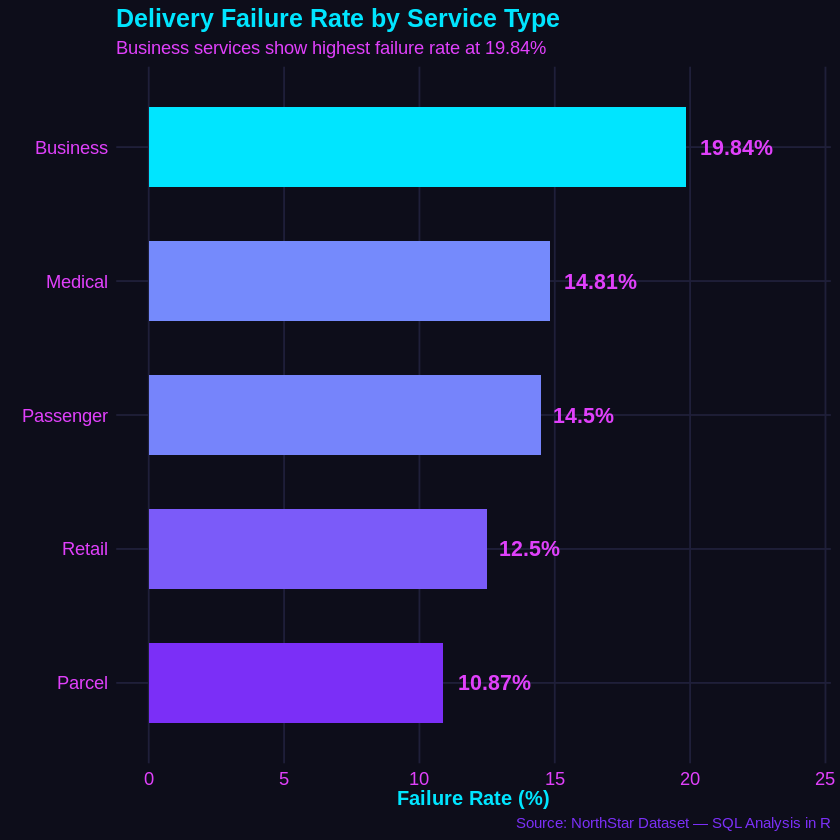

In [ ]:
ggplot(query1, aes(x=reorder(service_type, failure_rate_pct), y=failure_rate_pct, fill=failure_rate_pct)) +
  geom_bar(stat="identity", width=0.6) +
  geom_text(aes(label=paste0(failure_rate_pct, "%")), hjust=-0.2, size=4.5,
            color="#e040fb", fontface="bold") +
  scale_fill_gradient(low="#7b2ff7", high="#00e5ff") +
  scale_y_continuous(limits=c(0, 24)) +  # ← fixes cut-off label
  coord_flip() +
  labs(
    title="Delivery Failure Rate by Service Type",
    subtitle="Business services show highest failure rate at 19.84%",
    x=NULL,                               # ← removes sideways "Service Type"
    y="Failure Rate (%)",
    caption="Source: NorthStar Dataset — SQL Analysis in R"
  ) +
  theme_minimal() +
  theme(
    legend.position    = "none",
    plot.background    = element_rect(fill="#0d0d1a", color=NA),
    panel.background   = element_rect(fill="#0d0d1a", color=NA),
    panel.grid.major   = element_line(color="#1f1f3a", linewidth=0.5),
    panel.grid.minor   = element_blank(),
    plot.title         = element_text(color="#00e5ff", face="bold", size=15),
    plot.subtitle      = element_text(color="#e040fb", size=11),
    plot.caption       = element_text(color="#7b2ff7", size=9),
    axis.text          = element_text(color="#e040fb", size=11),
    axis.title         = element_text(color="#00e5ff", size=12, face="bold")
  )

**Chart Interpretation**: Business services dominate failure rates at 19.84%, visually standing out from all other service types. Parcel services at 10.87% perform best, suggesting simpler delivery requirements lead to better outcomes.

### Chart 2

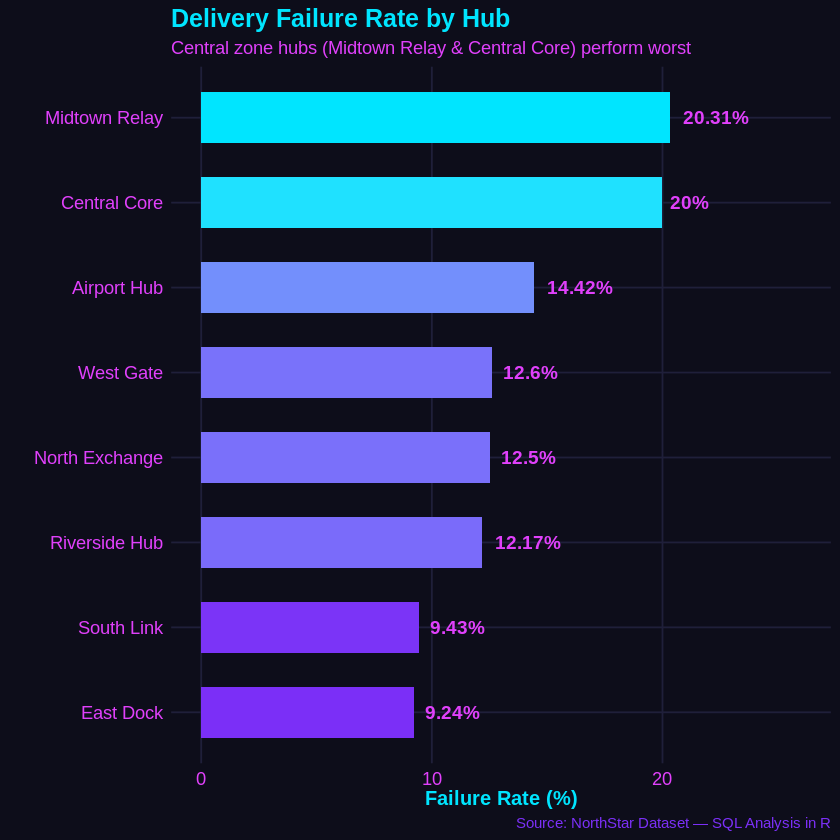

In [ ]:
ggplot(query2, aes(x=reorder(hub_name, failure_rate_pct), y=failure_rate_pct, fill=failure_rate_pct)) +
  geom_bar(stat="identity", width=0.6) +
  geom_text(aes(label=paste0(failure_rate_pct, "%")), hjust=-0.2, size=4,
            color="#e040fb", fontface="bold") +
  scale_fill_gradient(low="#7b2ff7", high="#00e5ff") +
  scale_y_continuous(limits=c(0, 26)) +
  coord_flip() +
  labs(
    title="Delivery Failure Rate by Hub",
    subtitle="Central zone hubs (Midtown Relay & Central Core) perform worst",
    x=NULL,
    y="Failure Rate (%)",
    caption="Source: NorthStar Dataset — SQL Analysis in R"
  ) +
  theme_minimal() +
  theme(
    legend.position    = "none",
    plot.background    = element_rect(fill="#0d0d1a", color=NA),
    panel.background   = element_rect(fill="#0d0d1a", color=NA),
    panel.grid.major   = element_line(color="#1f1f3a", linewidth=0.5),
    panel.grid.minor   = element_blank(),
    plot.title         = element_text(color="#00e5ff", face="bold", size=15),
    plot.subtitle      = element_text(color="#e040fb", size=11),
    plot.caption       = element_text(color="#7b2ff7", size=9),
    axis.text          = element_text(color="#e040fb", size=11),
    axis.title         = element_text(color="#00e5ff", size=12, face="bold")
  )

**Chart Interpretation**: The two Central zone hubs (Midtown Relay 20.31%, Central Core 20.00%) are clearly the worst performers, shown by the longest cyan bars. East Dock and South Link at the bottom confirm the South and East zones operate more reliably than Central.

### Chart 3

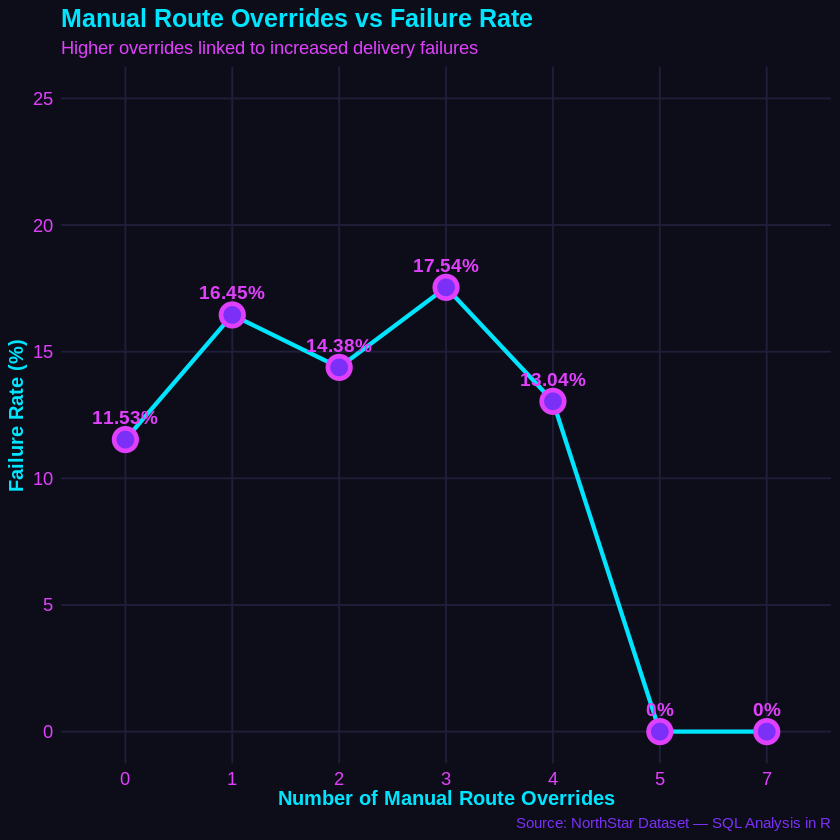

In [ ]:
ggplot(query3, aes(x=factor(manual_route_override_count), y=failure_rate_pct)) +
  geom_line(aes(group=1), color="#00e5ff", linewidth=1.2) +
  geom_point(size=5, color="#e040fb", fill="#7b2ff7", shape=21, stroke=2) +
  geom_text(aes(label=paste0(failure_rate_pct, "%")), vjust=-1.2, size=4,
            color="#e040fb", fontface="bold") +
  scale_y_continuous(limits=c(0, 25)) +
  labs(
    title="Manual Route Overrides vs Failure Rate",
    subtitle="Higher overrides linked to increased delivery failures",
    x="Number of Manual Route Overrides",
    y="Failure Rate (%)",
    caption="Source: NorthStar Dataset — SQL Analysis in R"
  ) +
  theme_minimal() +
  theme(
    plot.background    = element_rect(fill="#0d0d1a", color=NA),
    panel.background   = element_rect(fill="#0d0d1a", color=NA),
    panel.grid.major   = element_line(color="#1f1f3a", linewidth=0.5),
    panel.grid.minor   = element_blank(),
    plot.title         = element_text(color="#00e5ff", face="bold", size=15),
    plot.subtitle      = element_text(color="#e040fb", size=11),
    plot.caption       = element_text(color="#7b2ff7", size=9),
    axis.text          = element_text(color="#e040fb", size=11),
    axis.title         = element_text(color="#00e5ff", size=12, face="bold")
  )

**Chart Interpretation**: The line peaks at 3 overrides (17.54%) before dropping sharply. The 0% at 5 and 7 overrides should be treated with caution as these represent only 7 and 1 deliveries respectively, too small to be statistically meaningful. The overall trend from 0 to 3 overrides shows a clear
increase in failure risk.

### Chart 4

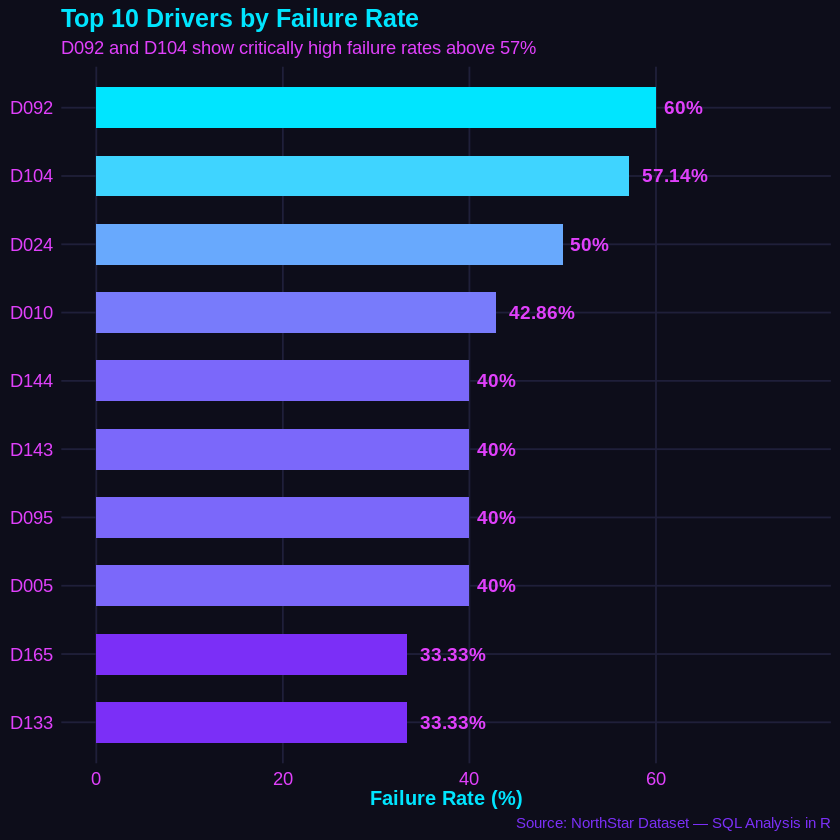

In [ ]:
ggplot(query4, aes(x=reorder(driver_id, failure_rate_pct), y=failure_rate_pct, fill=failure_rate_pct)) +
  geom_bar(stat="identity", width=0.6) +
  geom_text(aes(label=paste0(failure_rate_pct, "%")), hjust=-0.2, size=4,
            color="#e040fb", fontface="bold") +
  scale_fill_gradient(low="#7b2ff7", high="#00e5ff") +
  scale_y_continuous(limits=c(0, 75)) +
  coord_flip() +
  labs(
    title="Top 10 Drivers by Failure Rate",
    subtitle="D092 and D104 show critically high failure rates above 57%",
    x=NULL,
    y="Failure Rate (%)",
    caption="Source: NorthStar Dataset — SQL Analysis in R"
  ) +
  theme_minimal() +
  theme(
    legend.position    = "none",
    plot.background    = element_rect(fill="#0d0d1a", color=NA),
    panel.background   = element_rect(fill="#0d0d1a", color=NA),
    panel.grid.major   = element_line(color="#1f1f3a", linewidth=0.5),
    panel.grid.minor   = element_blank(),
    plot.title         = element_text(color="#00e5ff", face="bold", size=15),
    plot.subtitle      = element_text(color="#e040fb", size=11),
    plot.caption       = element_text(color="#7b2ff7", size=9),
    axis.text          = element_text(color="#e040fb", size=11),
    axis.title         = element_text(color="#00e5ff", size=12, face="bold")
  )


**Chart Interpretation**: D092 (60%) and D104 (57.14%) show dangerously high failure rates. Four drivers share exactly 40% failure rate, suggesting a systemic zone or scheduling issue rather than isolated individual performance.
NorthStar should investigate route assignments rather than solely
focusing on individual driver performance.